# Exploratory analysis

Everything here reads `panel_hourly` and `panel_monthly` from the
`swedish_electricity` database and writes nothing back. The point is to look at the
data before specifying a model: what the price levels and spreads actually are, how
wind moves against price, what the daily and seasonal shape is, which variables are
collinear, and whether the series are stationary.

Every figure is saved to `figures/` as a 150 dpi PNG so it can be reused in the
write-up and the dashboard.

**A note that applies throughout.** Flows and generation are national series and
were attached to all four zones in Panel A, so they repeat across zones. Anything
summarised from them is therefore de-duplicated to one row per hour first, and any
chart of them is a national chart even when the price beside it is zonal.

File paths below are relative to the repository root. Run from the project root or `notebooks/`.

In [1]:
from pathlib import Path

# Resolve paths from the repository root when launched here or from notebooks/.
PROJECT_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'data' / 'raw').is_dir() and (path / 'notebooks').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Run this notebook from the project root or notebooks/ folder.')

import os
import subprocess
import sys
import warnings

for package in ['seaborn', 'statsmodels']:
    try:
        __import__(package)
    except ImportError:
        print(f'installing {package}')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', package], check=True)

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels
from sqlalchemy import create_engine

print('pandas', pd.__version__, '| matplotlib', matplotlib.__version__,
      '| seaborn', sns.__version__, '| statsmodels', statsmodels.__version__)

pandas 3.0.3 | matplotlib 3.11.0 | seaborn 0.13.2 | statsmodels 0.14.6


In [2]:
%matplotlib inline

FIG_DIR = PROJECT_ROOT / 'figures'
LI_DIR = os.path.join(FIG_DIR, 'linkedin')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(LI_DIR, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ZONES = ['SE1', 'SE2', 'SE3', 'SE4']
# Two blues for the northern zones, two oranges for the southern pair, so the
# north/south split the analysis turns on is legible before the legend is read.
ZONE_COLOUR = {'SE1': '#378ADD', 'SE2': '#85B7EB', 'SE3': '#D85A30', 'SE4': '#F0997B'}

# 1080 x 1350 at 200 dpi: the portrait size used for the shareable copies.
LI_FIGSIZE = (1080 / 200, 1350 / 200)

plt.rcParams.update({
    'savefig.dpi': 200,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlepad': 12,
    'text.color': '#1A1A1A',
    'axes.labelcolor': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})


def tidy_axes(ax, grid='y'):
    """Shared look: no top or right spine, one faint grid direction."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_color('#B0B0B0')
        ax.spines[side].set_linewidth(1.0)
    ax.grid(False)
    if grid:
        ax.grid(True, axis=grid, color='#DDDDDD', linewidth=0.7)
        ax.set_axisbelow(True)
    return ax


def save_linkedin(fig, name):
    """Write an exact 1080 x 1350 copy to figures/linkedin/<name>.png.

    bbox_inches is deliberately left off here: it retrims the canvas and would
    break the pixel dimensions.
    """
    path = os.path.join(LI_DIR, name + '.png')
    fig.savefig(path, dpi=200)
    print('saved', path)
    return path


def save_fig(fig, name, dpi=200):
    """Write a figure to figures/<name>.png."""
    path = os.path.join(FIG_DIR, name + '.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print('saved', path)
    return path


print('figures will be written to', os.path.abspath(FIG_DIR))

figures will be written to C:\Users\ewuzi\Downloads\Project\figures


In [3]:
# Credentials are read from the repository-root .env, which is gitignored. Copy .env.example to .env
# and set PG_URL there.
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / '.env')
ENGINE_URL = os.environ["PG_URL"]
engine = create_engine(ENGINE_URL)

# Read-only: this notebook never writes to the database.
hourly = pd.read_sql('select * from panel_hourly order by ts_utc, zone', engine)
monthly = pd.read_sql('select * from panel_monthly order by zone, year, month', engine)
# psycopg2 returns timestamptz values with the session offset attached, which can
# leave the column as object dtype. Forcing the conversion here guarantees a real
# DatetimeIndex for every resample and .dt accessor further down.
hourly['ts_utc'] = pd.to_datetime(hourly['ts_utc'], utc=True)
hourly['ts_local'] = pd.to_datetime(hourly['ts_local'])
print('loaded both panels')
print('ts_utc dtype:', hourly['ts_utc'].dtype, '| ts_local dtype:', hourly['ts_local'].dtype)

loaded both panels
ts_utc dtype: datetime64[us, UTC] | ts_local dtype: datetime64[us]


In [4]:
print('panel_hourly ', hourly.shape)
print('panel_monthly', monthly.shape)
print('hourly range :', hourly['ts_utc'].min(), 'to', hourly['ts_utc'].max())
hourly.head(3)

panel_hourly  (171478, 29)
panel_monthly (240, 37)
hourly range : 2021-01-01 00:00:00+00:00 to 2025-12-31 22:00:00+00:00


,ts_utc,zone,ts_local,year,month,day_of_week,hour,price_eur_mwh,temp_c,temp_quality,...,fossil_gas_mw,hydro_reservoir_mw,other_mw,wind_onshore_mw,solar_mw,load_mw,residual_load_mw,renewable_share_load_pct,renewable_share_generation_pct,wind_decile
0,2021-01-01 00:00:00+00:00,SE4,2021-01-01 01:00:00,2021,1,5,1,24.35,1.0,G,...,0.0,10419.0,1038.0,978.0,0.0,15507.0,14529.0,73.5,59.3,1
1,2021-01-01 01:00:00+00:00,SE4,2021-01-01 02:00:00,2021,1,5,2,23.98,1.3,G,...,0.0,10280.0,1010.0,913.0,0.0,15130.0,14217.0,74.0,59.0,1
2,2021-01-01 02:00:00+00:00,SE4,2021-01-01 03:00:00,2021,1,5,3,23.72,1.4,G,...,0.0,10221.0,997.0,914.0,0.0,14917.0,14003.0,74.6,58.9,1


In [5]:
# Wide price frame, one column per zone. The primary key on (ts_utc, zone)
# guarantees this pivot is lossless.
price_wide = hourly.pivot(index='ts_utc', columns='zone', values='price_eur_mwh').sort_index()
temp_wide = hourly.pivot(index='ts_utc', columns='zone', values='temp_c').sort_index()

# National series: one row per hour, since these repeat identically across zones.
NATIONAL_COLS = ['wind_onshore_mw', 'solar_mw', 'load_mw', 'residual_load_mw',
                 'nuclear_mw', 'hydro_reservoir_mw', 'fossil_gas_mw', 'other_mw',
                 'flow_sum_gw', 'cross_border_trading_mw']
national = (hourly.drop_duplicates(subset=['ts_utc'])
                  .set_index('ts_utc')[NATIONAL_COLS + ['year', 'month', 'hour']]
                  .sort_index())

print('price_wide', price_wide.shape, '| national', national.shape)
print('national series are identical across zones:',
      bool(hourly.groupby('ts_utc')['load_mw'].nunique().max() == 1))
national.head(3)

price_wide (43499, 4) | national (43499, 13)
national series are identical across zones: True


,wind_onshore_mw,solar_mw,load_mw,residual_load_mw,nuclear_mw,hydro_reservoir_mw,fossil_gas_mw,other_mw,flow_sum_gw,cross_border_trading_mw,year,month,hour
ts_utc,,,,,,,,,,,,,
2021-01-01 00:00:00+00:00,978.0,0.0,15507.0,14529.0,6773.0,10419.0,0.0,1038.0,-4.096,-4143.7,2021,1,1
2021-01-01 01:00:00+00:00,913.0,0.0,15130.0,14217.0,6772.0,10280.0,0.0,1010.0,-4.228,-4355.9,2021,1,2
2021-01-01 02:00:00+00:00,914.0,0.0,14917.0,14003.0,6775.0,10221.0,0.0,997.0,-4.332,-4389.4,2021,1,3


## 1. Descriptive statistics

The same seven statistics for every series, so the tables are comparable. `p5` and
`p95` matter more than the min and max here: electricity prices have long tails in
both directions and the extremes are single hours, not a description of the level.

In [6]:
def describe_by(frame, value, by):
    """Standard summary of one column, grouped."""
    grouped = frame.groupby(by)[value]
    out = pd.DataFrame({
        'n': grouped.size(),
        'mean': grouped.mean(),
        'median': grouped.median(),
        'std': grouped.std(),
        'min': grouped.min(),
        'p5': grouped.quantile(0.05),
        'p95': grouped.quantile(0.95),
        'max': grouped.max(),
    })
    return out.round(2)

describe_by(hourly, 'price_eur_mwh', 'zone')

,n,mean,median,std,min,p5,p95,max
zone,,,,,,,,
SE1,42743,36.97,24.93,46.65,-60.04,0.37,108.19,590.00
SE2,42730,37.51,25.35,47.55,-60.04,0.07,110.07,590.00
SE3,42949,66.08,42.78,78.83,-60.04,0.97,209.29,799.97
SE4,43056,81.78,60.17,87.30,-60.04,1.22,245.50,799.97


Now the same split by year. 2022 should stand out on its own row rather than being
something asserted in a sentence.

In [7]:
price_by_year = describe_by(hourly, 'price_eur_mwh', ['zone', 'year'])
price_by_year

n    mean  median     std    min     p5     p95     max
zone year                                                            
SE1  2021  8592   42.56   40.34   28.94  -1.97  13.36   84.83  360.00
     2022  8592   59.33   29.58   79.09  -2.08   3.06  240.07  590.00
     2023  8564   40.07   32.22   34.03 -60.04   0.00  102.35  332.00
     2024  8583   25.42   18.84   26.90 -48.69  -0.12   72.65  526.25
     2025  8412   17.09    6.12   28.50 -33.79  -0.04   81.21  275.19
SE2  2021  8536   42.75   40.49   29.01  -1.41  13.54   85.94  360.00
     2022  8594   62.27   31.08   80.42  -2.08   3.89  248.53  590.00
     2023  8613   40.03   32.21   34.09 -60.04   0.00  102.38  332.00
     2024  8586   25.06   18.61   27.17 -59.96  -0.57   72.61  526.25
     2025  8401   17.00    5.35   29.00 -25.22  -0.51   83.17  269.26
SE3  2021  8628   66.18   51.00   59.50  -1.97  14.06  178.09  626.06
     2022  8625  129.63   94.95  128.21  -2.08   4.69  404.98  799.97
     2023  8617   51.85   39.00   45.30 -60.04   0.00  139.92  332.00
     2024  8601   36.33   25.76   40.46 -59.96  -0.20  105.48  707.52
     2025  8478   45.97   35.52   42.32 -25.05   0.27  128.85  413.16
SE4  2021  8640   80.48   63.78   63.84  -1.91  15.08  203.15  626.06
     2022  8647  152.44  121.88  140.47  -2.08   5.12  453.52  799.97
     2023  8635   64.94   56.93   50.50 -60.04   0.09  155.52  332.00
     2024  8647   50.39   39.52   50.48 -59.96  -0.16  132.03  699.09
     2025  8487   60.25   54.68   48.73 -25.30   0.21  145.61  426.44

In [8]:
# Temperature is genuinely zonal, so it gets the same zone-by-year treatment.
describe_by(hourly, 'temp_c', ['zone', 'year'])

n  mean  median    std   min     p5    p95   max
zone year                                                     
SE1  2021  8592  2.68    3.00  10.94 -29.1 -15.74  19.30  27.5
     2022  8592  3.65    3.90   9.93 -27.2 -14.10  18.40  27.7
     2023  8564  2.85    1.35  10.60 -24.3 -13.90  18.80  26.6
     2024  8583  3.66    3.30  11.49 -36.4 -17.80  19.40  24.8
     2025  8412  4.41    4.40  10.09 -24.5 -13.60  20.50  31.2
SE2  2021  8536  3.20    3.70   9.60 -23.9 -13.50  18.30  27.0
     2022  8594  4.28    4.60   8.24 -21.4  -8.70  17.40  28.3
     2023  8613  3.03    2.30   9.50 -21.6 -12.74  17.40  25.4
     2024  8586  4.68    4.20   9.16 -28.6 -11.18  18.50  28.2
     2025  8401  5.24    4.70   7.97 -19.0  -7.20  18.70  28.8
SE3  2021  8628  6.22    6.10   8.87 -20.3  -8.70  20.60  28.5
     2022  8625  6.83    7.00   8.18 -21.9  -5.78  20.40  30.8
     2023  8617  6.08    4.80   8.52 -21.6  -6.70  19.52  26.6
     2024  8601  6.97    6.30   8.70 -20.5  -6.40  20.70  29.9
     2025  8478  7.33    6.70   7.73 -14.9  -4.60  19.90  27.3
SE4  2021  8640  8.95    8.90   7.70 -12.6  -3.20  21.50  30.9
     2022  8647  9.60   10.10   6.97 -12.5  -0.80  20.80  31.3
     2023  8635  9.45    8.70   7.04 -10.2  -1.30  20.80  27.1
     2024  8647  9.88    9.70   7.08 -13.2  -0.77  21.20  30.8
     2025  8487  9.75    9.50   6.84 -10.3  -0.60  20.90  29.1

In [9]:
# Wind and load are national, so a zone breakdown would just repeat one series four
# times. They are summarised by year on the de-duplicated national frame instead.
national_long = national.reset_index()
wind_by_year = describe_by(national_long, 'wind_onshore_mw', 'year')
load_by_year = describe_by(national_long, 'load_mw', 'year')
print('national wind, MW')
print(wind_by_year.to_string())
print()
print('national load, MW')
print(load_by_year.to_string())

national wind, MW
         n     mean  median      std    min      p5      p95      max
year                                                                 
2021  8753  3044.13  2641.0  1910.08  166.0  646.60  6808.20   9539.0
2022  8736  3735.79  3357.3  2208.29  152.1  758.90  8128.90  12060.8
2023  8722  3890.25  3349.1  2376.58   82.9  850.95  8503.98  12639.4
2024  8721  4580.71  4070.5  2819.00  130.5  901.90  9993.40  13528.2
2025  8567  4432.82  4192.2  2564.30  220.9  875.10  9243.07  12683.1

national load, MW
         n      mean   median      std     min        p5       p95      max
year                                                                       
2021  8753  15916.64  15350.0  3592.09  8865.0  10800.60  22704.80  25657.0
2022  8736  15087.28  14546.5  3117.34  9013.0  10758.75  20625.25  24250.0
2023  8722  14915.32  14492.5  3195.78  8259.0  10313.10  20232.85  24332.0
2024  8721  15028.26  14512.0  3357.36  8677.0  10252.00  20983.00  25756.0
2025  8567  14816

## 2. Price levels and the zone gap

saved C:\Users\ewuzi\Downloads\Project\figures\02_daily_price_by_zone.png


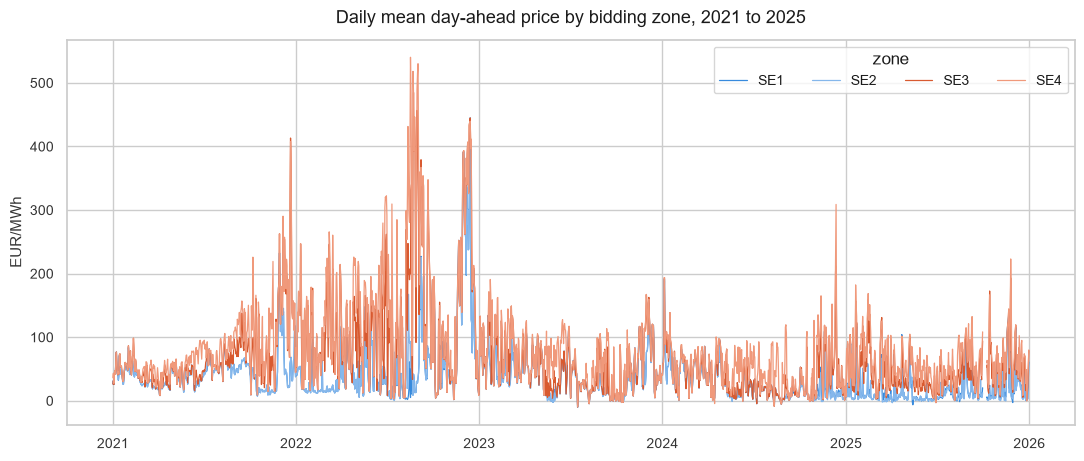

In [10]:
# Daily means, not hourly, so five years fit in one readable chart. The hourly
# variation is real but it turns a line chart into a solid block.
daily_price = price_wide.resample('D').mean()

fig, ax = plt.subplots(figsize=(13, 5))
for zone in ZONES:
    ax.plot(daily_price.index, daily_price[zone], label=zone,
            color=ZONE_COLOUR[zone], linewidth=0.9)
ax.set_title('Daily mean day-ahead price by bidding zone, 2021 to 2025')
ax.set_ylabel('EUR/MWh')
ax.set_xlabel('')
ax.legend(title='zone', ncol=4)
save_fig(fig, '02_daily_price_by_zone')
plt.show()

saved C:\Users\ewuzi\Downloads\Project\figures\02_spread_se4_se1.png


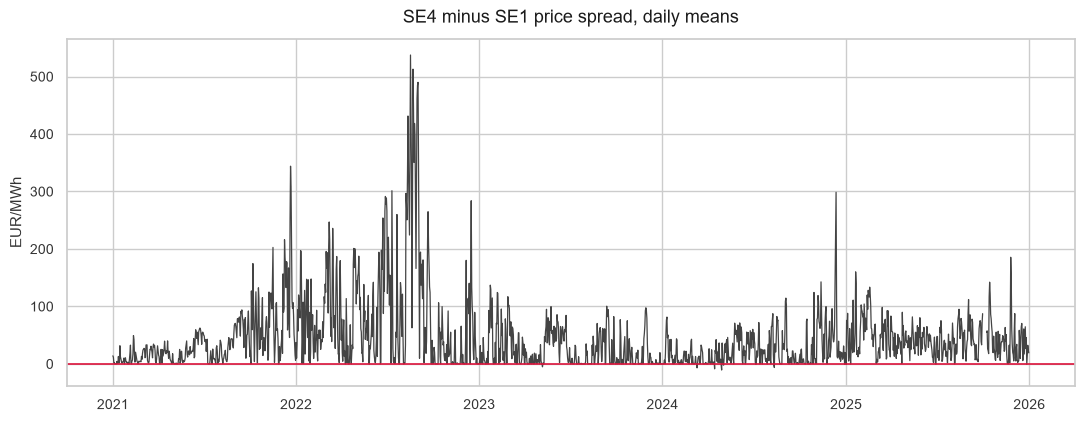

In [11]:
# SE4 is the southern, import-dependent zone; SE1 is the northern, hydro-heavy one.
# The gap between them is the clearest single summary of Sweden's internal split.
spread_daily = (price_wide['SE4'] - price_wide['SE1']).resample('D').mean()

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(spread_daily.index, spread_daily.values, color='#444444', linewidth=0.9)
ax.axhline(0, color='crimson', linewidth=1.2)
ax.set_title('SE4 minus SE1 price spread, daily means')
ax.set_ylabel('EUR/MWh')
ax.set_xlabel('')
save_fig(fig, '02_spread_se4_se1')
plt.show()

In [12]:
PAIRS = [('SE4', 'SE1'), ('SE4', 'SE2'), ('SE4', 'SE3'),
         ('SE3', 'SE1'), ('SE3', 'SE2'), ('SE2', 'SE1')]
spreads = pd.DataFrame({f'{a} - {b}': price_wide[a] - price_wide[b] for a, b in PAIRS})
spread_by_year = spreads.groupby(spreads.index.year).mean().round(2)
spread_by_year.index.name = 'year'
print('mean hourly spread by year, EUR/MWh')
spread_by_year

mean hourly spread by year, EUR/MWh


,SE4 - SE1,SE4 - SE2,SE4 - SE3,SE3 - SE1,SE3 - SE2,SE2 - SE1
year,,,,,,
2021,37.88,37.88,14.49,23.57,23.60,0.06
2022,92.61,90.00,22.72,69.87,67.22,2.81
2023,24.62,24.79,13.20,11.71,11.71,0.01
2024,24.92,25.21,14.02,10.88,11.21,-0.40
2025,43.26,43.42,14.38,28.90,29.13,-0.18


C:\Users\ewuzi\AppData\Local\Temp\ipykernel_10148\2391635473.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hourly, x='zone', y='price_eur_mwh', order=ZONES,


saved C:\Users\ewuzi\Downloads\Project\figures\02_price_boxplot_by_zone.png


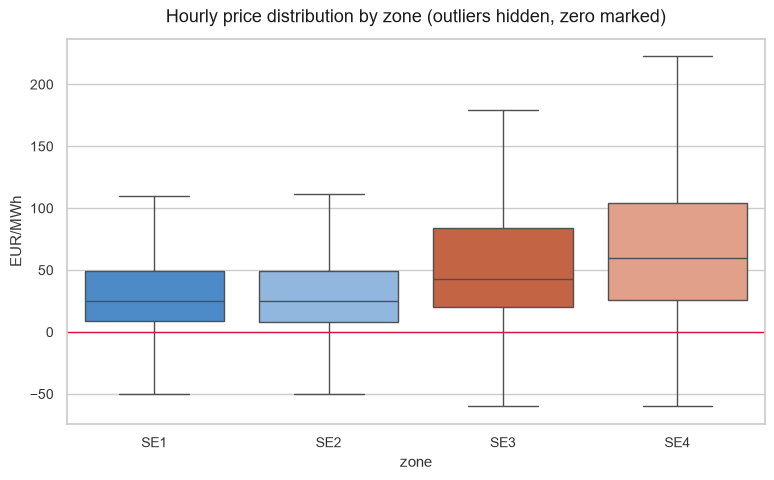

In [13]:
# Distribution of hourly prices. The y axis is clipped so the box is readable; the
# tails beyond the clip are real and are described by the table in section 1.
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=hourly, x='zone', y='price_eur_mwh', order=ZONES,
            palette=[ZONE_COLOUR[z] for z in ZONES], ax=ax, showfliers=False)
ax.axhline(0, color='crimson', linewidth=1)
ax.set_title('Hourly price distribution by zone (outliers hidden, zero marked)')
ax.set_ylabel('EUR/MWh')
save_fig(fig, '02_price_boxplot_by_zone')
plt.show()

In [14]:
negative = hourly[hourly['price_eur_mwh'] < 0]
neg_by_zone_year = (negative.pivot_table(index='year', columns='zone',
                                         values='price_eur_mwh', aggfunc='size')
                            .reindex(columns=ZONES).fillna(0).astype(int))
print(f'hours with a negative price: {len(negative):,} of {len(hourly):,} '
      f'({100 * len(negative) / len(hourly):.2f}%)')
print(f'most negative single hour: {negative["price_eur_mwh"].min():.2f} EUR/MWh')
print()
print('count of negative-price hours by year and zone')
neg_by_zone_year

hours with a negative price: 6,051 of 171,478 (3.53%)
most negative single hour: -60.04 EUR/MWh

count of negative-price hours by year and zone


zone,SE1,SE2,SE3,SE4
year,,,,
2021,10,5,12,11
2022,27,26,27,27
2023,409,421,414,353
2024,588,681,617,599
2025,489,652,330,353


## 3. The merit-order relationship

Wind has near-zero marginal cost, so more wind pushes the supply curve right and
the marginal unit down it. If that mechanism is present in this data it should show
as a downward slope of price against wind, steeper where the curve is steep.

saved C:\Users\ewuzi\Downloads\Project\figures\03_hexbin_wind_vs_price.png


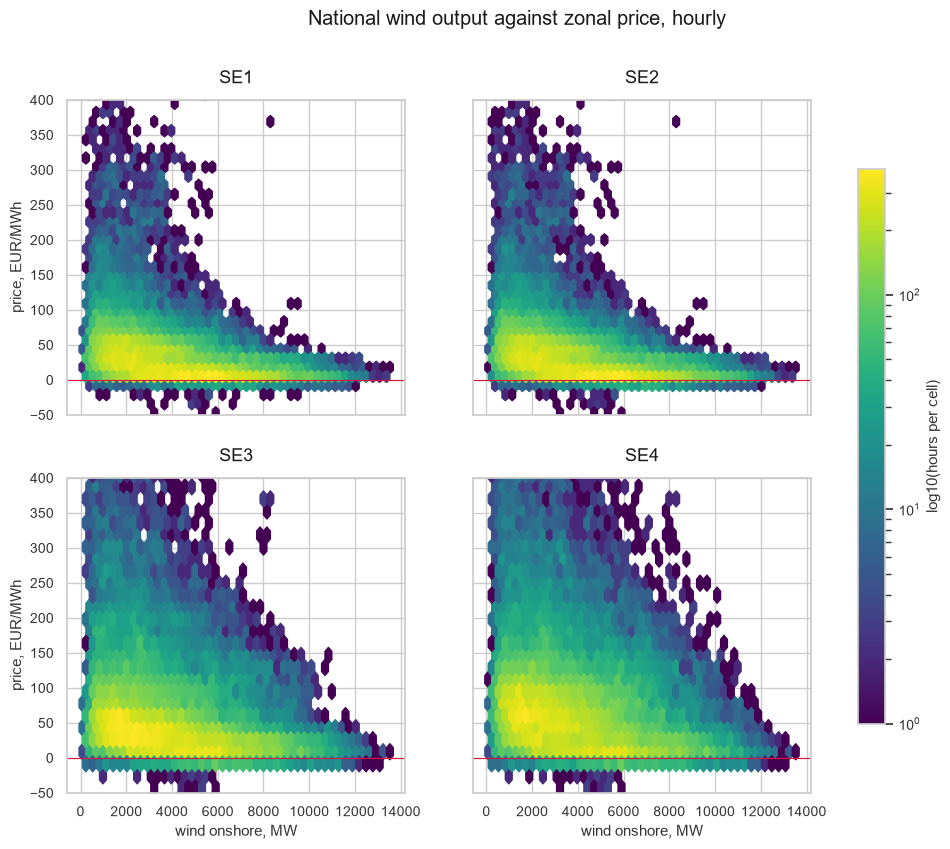

In [15]:
# 171,478 points would be a solid blob, so this is a hexbin with a log colour scale
# rather than a scatter. Density is the information here, not individual hours.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True, sharey=True)
for ax, zone in zip(axes.flat, ZONES):
    sub = hourly[hourly['zone'] == zone]
    hb = ax.hexbin(sub['wind_onshore_mw'], sub['price_eur_mwh'],
                   gridsize=45, cmap='viridis', mincnt=1, bins='log')
    ax.set_title(zone)
    ax.set_ylim(-50, 400)
    ax.axhline(0, color='crimson', linewidth=0.8)
fig.colorbar(hb, ax=axes, label='log10(hours per cell)', shrink=0.8)
fig.suptitle('National wind output against zonal price, hourly', y=0.98)
for ax in axes[1]:
    ax.set_xlabel('wind onshore, MW')
for ax in axes[:, 0]:
    ax.set_ylabel('price, EUR/MWh')
save_fig(fig, '03_hexbin_wind_vs_price')
plt.show()

saved C:\Users\ewuzi\Downloads\Project\figures\03_price_by_wind_decile.png


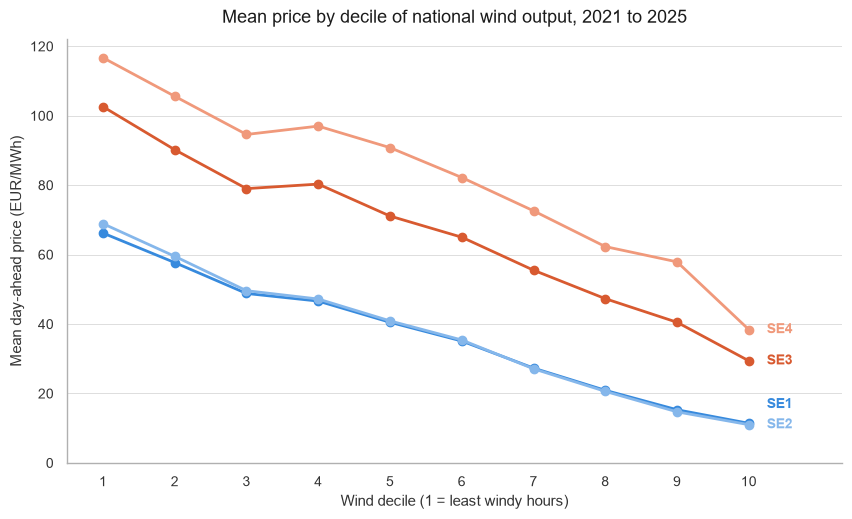

saved C:\Users\ewuzi\Downloads\Project\figures\linkedin\03_price_by_wind_decile.png


zone,SE1,SE2,SE3,SE4
wind_decile,,,,
1,66.2,68.9,102.6,116.7
2,57.7,59.5,90.2,105.6
3,48.8,49.6,79.0,94.6
4,46.6,47.2,80.3,97.0
5,40.5,40.9,71.1,90.8
6,35.1,35.4,65.0,82.2
7,27.3,27.1,55.5,72.6
8,20.9,20.6,47.3,62.3
9,15.3,14.7,40.5,57.9


In [16]:
# The decile labels come straight from panel_hourly, so this chart bins on exactly
# the NTILE(10) buckets that 03_build_panels wrote to the database. They used to be
# recomputed here with pd.qcut, which assigned 21 of 171,478 rows to a different
# bucket and moved no decile mean by more than 0.03 EUR/MWh.
decile_price = hourly.pivot_table(index='wind_decile', columns='zone',
                                  values='price_eur_mwh', aggfunc='mean').round(1)


def draw_decile(ax, linewidth=2.0, markersize=6, label_size=10):
    """Four zone lines, each labelled at its right end as well as in the legend."""
    for zone in ZONES:
        ax.plot(decile_price.index, decile_price[zone], marker='o',
                linewidth=linewidth, markersize=markersize,
                label=zone, color=ZONE_COLOUR[zone])
    # SE1 and SE2 converge in the windiest decile, so spread the end labels apart
    # rather than letting them print on top of one another.
    ends = {z: float(decile_price[z].iloc[-1]) for z in ZONES}
    gap = float(decile_price.to_numpy().max()) * 0.05
    placed, last = {}, None
    for z in sorted(ends, key=ends.get):
        y = ends[z] if last is None else max(ends[z], last + gap)
        placed[z], last = y, y
    for z in ZONES:
        ax.annotate(z, (10.25, placed[z]),
                    color=ZONE_COLOUR[z], fontsize=label_size,
                    fontweight='bold', va='center')
    ax.set_xticks(range(1, 11))
    ax.set_xlim(0.5, 11.3)
    ax.set_ylim(0, None)
    ax.set_xlabel('Wind decile (1 = least windy hours)')
    ax.set_ylabel('Mean day-ahead price (EUR/MWh)')
    tidy_axes(ax)


fig, ax = plt.subplots(figsize=(10, 5.5))
draw_decile(ax)
ax.set_title('Mean price by decile of national wind output, 2021 to 2025')
save_fig(fig, '03_price_by_wind_decile')
plt.show()

fig_li = plt.figure(figsize=LI_FIGSIZE, layout='constrained')
ax_li = fig_li.add_subplot()
draw_decile(ax_li, linewidth=2.6, markersize=8, label_size=13)
ax_li.set_title('Mean price by decile of national wind output\nSweden, SE1 to SE4, 2021 to 2025', fontsize=16)
ax_li.xaxis.label.set_size(13)
ax_li.yaxis.label.set_size(13)
ax_li.tick_params(labelsize=12)
save_linkedin(fig_li, '03_price_by_wind_decile')
plt.close(fig_li)

decile_price

saved C:\Users\ewuzi\Downloads\Project\figures\03_price_by_wind_decile_by_year.png


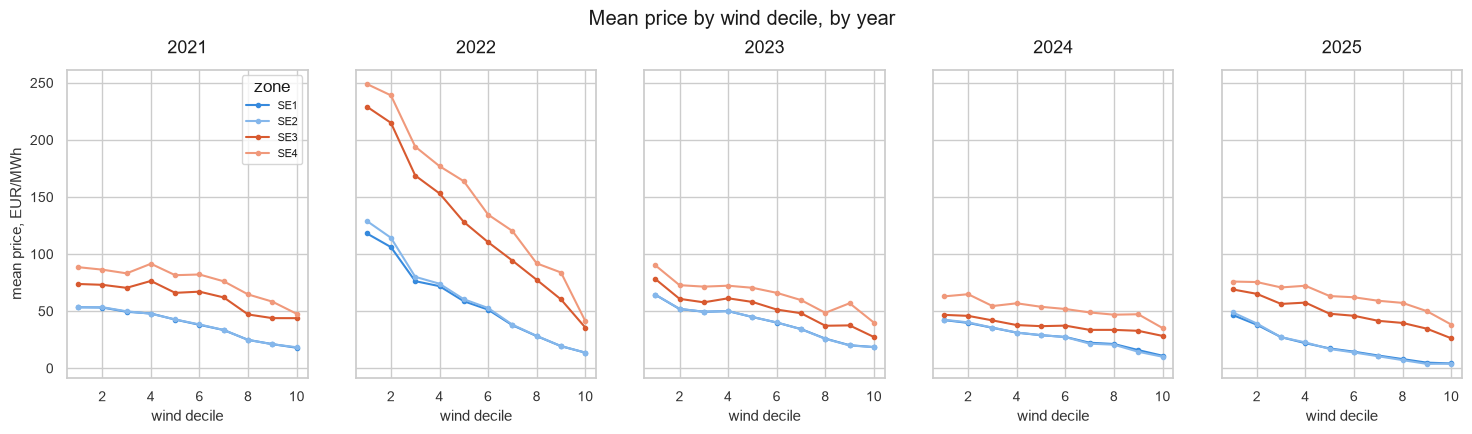

In [17]:
# Same picture year by year. If 2022 behaves differently, it shows here as a line
# that sits far above the others rather than as a different shape.
decile_year = (hourly.groupby(['year', 'wind_decile', 'zone'])['price_eur_mwh']
                     .mean().reset_index())

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharex=True, sharey=True)
for ax, year in zip(axes, sorted(hourly['year'].unique())):
    sub = decile_year[decile_year['year'] == year]
    for zone in ZONES:
        zsub = sub[sub['zone'] == zone]
        ax.plot(zsub['wind_decile'], zsub['price_eur_mwh'],
                marker='o', markersize=3, label=zone, color=ZONE_COLOUR[zone])
    ax.set_title(int(year))
    ax.set_xlabel('wind decile')
axes[0].set_ylabel('mean price, EUR/MWh')
axes[0].legend(title='zone', fontsize=8)
fig.suptitle('Mean price by wind decile, by year', y=1.03)
save_fig(fig, '03_price_by_wind_decile_by_year')
plt.show()

## 4. Temporal patterns

saved C:\Users\ewuzi\Downloads\Project\figures\04_price_by_hour_and_month.png


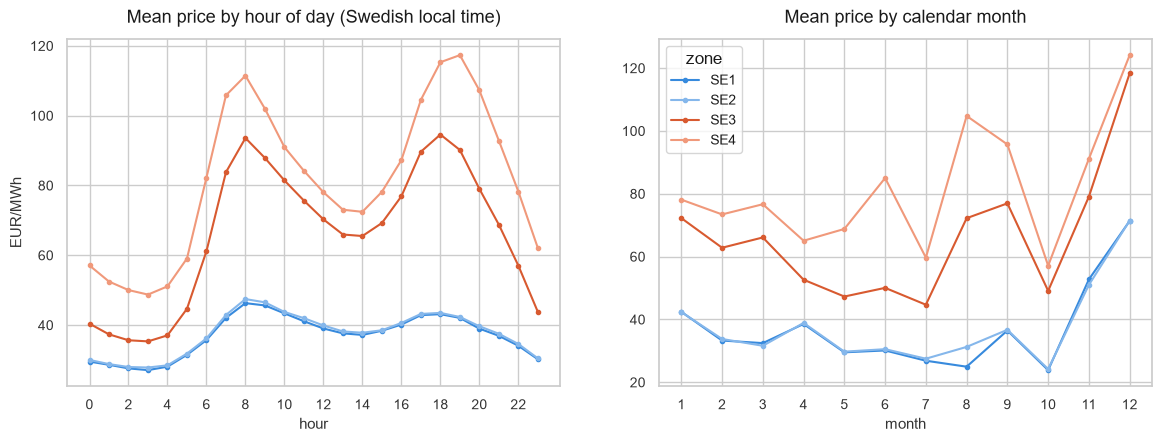

In [18]:
hour_price = hourly.pivot_table(index='hour', columns='zone', values='price_eur_mwh', aggfunc='mean')
month_price = hourly.pivot_table(index='month', columns='zone', values='price_eur_mwh', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for zone in ZONES:
    axes[0].plot(hour_price.index, hour_price[zone], marker='o', markersize=3,
                 label=zone, color=ZONE_COLOUR[zone])
    axes[1].plot(month_price.index, month_price[zone], marker='o', markersize=3,
                 label=zone, color=ZONE_COLOUR[zone])
axes[0].set_title('Mean price by hour of day (Swedish local time)')
axes[0].set_xlabel('hour')
axes[0].set_ylabel('EUR/MWh')
axes[0].set_xticks(range(0, 24, 2))
axes[1].set_title('Mean price by calendar month')
axes[1].set_xlabel('month')
axes[1].set_xticks(range(1, 13))
axes[1].legend(title='zone')
save_fig(fig, '04_price_by_hour_and_month')
plt.show()

saved C:\Users\ewuzi\Downloads\Project\figures\04_wind_and_load_profiles.png


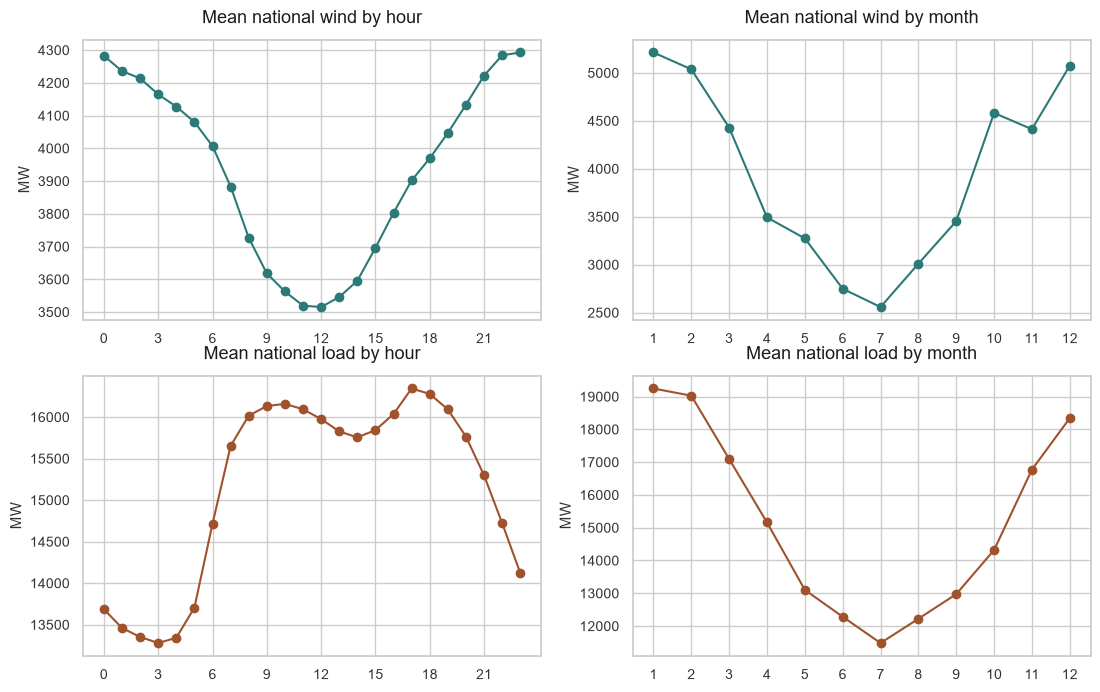

In [19]:
wind_hour = national.groupby('hour')['wind_onshore_mw'].mean()
wind_month = national.groupby('month')['wind_onshore_mw'].mean()
load_hour = national.groupby('hour')['load_mw'].mean()
load_month = national.groupby('month')['load_mw'].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes[0, 0].plot(wind_hour.index, wind_hour.values, marker='o', color='#2b7a78')
axes[0, 0].set_title('Mean national wind by hour')
axes[0, 1].plot(wind_month.index, wind_month.values, marker='o', color='#2b7a78')
axes[0, 1].set_title('Mean national wind by month')
axes[1, 0].plot(load_hour.index, load_hour.values, marker='o', color='#a0522d')
axes[1, 0].set_title('Mean national load by hour')
axes[1, 1].plot(load_month.index, load_month.values, marker='o', color='#a0522d')
axes[1, 1].set_title('Mean national load by month')
for ax in axes.flat:
    ax.set_ylabel('MW')
axes[0, 0].set_xticks(range(0, 24, 3))
axes[1, 0].set_xticks(range(0, 24, 3))
axes[0, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticks(range(1, 13))
save_fig(fig, '04_wind_and_load_profiles')
plt.show()

## 5. Relationships between variables

Zonal prices go in as four separate columns, everything else is the national series.
Temperature is the mean across the four station series, since one number per hour is
what a correlation matrix can use; the zonal temperatures are highly correlated with
each other anyway.

In [20]:
features = price_wide.rename(columns=lambda z: f'price_{z}')
features = features.join(national[['wind_onshore_mw', 'solar_mw', 'load_mw',
                                   'residual_load_mw', 'nuclear_mw',
                                   'hydro_reservoir_mw', 'flow_sum_gw']])
features['temp_c_mean'] = temp_wide.mean(axis=1)
corr = features.corr()
print('correlation matrix,', features.shape[1], 'variables,', f'{len(features):,} hours')
corr.round(2)

correlation matrix, 12 variables, 43,499 hours


,price_SE1,price_SE2,price_SE3,price_SE4,wind_onshore_mw,solar_mw,load_mw,residual_load_mw,nuclear_mw,hydro_reservoir_mw,flow_sum_gw,temp_c_mean
price_SE1,1.00,0.98,0.62,0.51,-0.36,-0.14,0.31,0.51,0.07,0.46,0.37,-0.27
price_SE2,0.98,1.00,0.63,0.53,-0.37,-0.13,0.29,0.50,0.07,0.46,0.36,-0.24
price_SE3,0.62,0.63,1.00,0.90,-0.27,-0.12,0.34,0.48,0.10,0.45,0.32,-0.19
price_SE4,0.51,0.53,0.90,1.00,-0.26,-0.13,0.24,0.39,0.05,0.37,0.27,-0.08
wind_onshore_mw,-0.36,-0.37,-0.27,-0.26,1.00,-0.16,0.19,-0.48,0.12,-0.48,-0.48,-0.23
solar_mw,-0.14,-0.13,-0.12,-0.13,-0.16,1.00,-0.23,-0.17,-0.28,-0.17,0.05,0.41
load_mw,0.31,0.29,0.34,0.24,0.19,-0.23,1.00,0.77,0.62,0.62,0.31,-0.79
residual_load_mw,0.51,0.50,0.48,0.39,-0.48,-0.17,0.77,1.00,0.48,0.87,0.58,-0.57
nuclear_mw,0.07,0.07,0.10,0.05,0.12,-0.28,0.62,0.48,1.00,0.33,-0.13,-0.61
hydro_reservoir_mw,0.46,0.46,0.45,0.37,-0.48,-0.17,0.62,0.87,0.33,1.00,0.24,-0.45


saved C:\Users\ewuzi\Downloads\Project\figures\05_correlation_heatmap.png


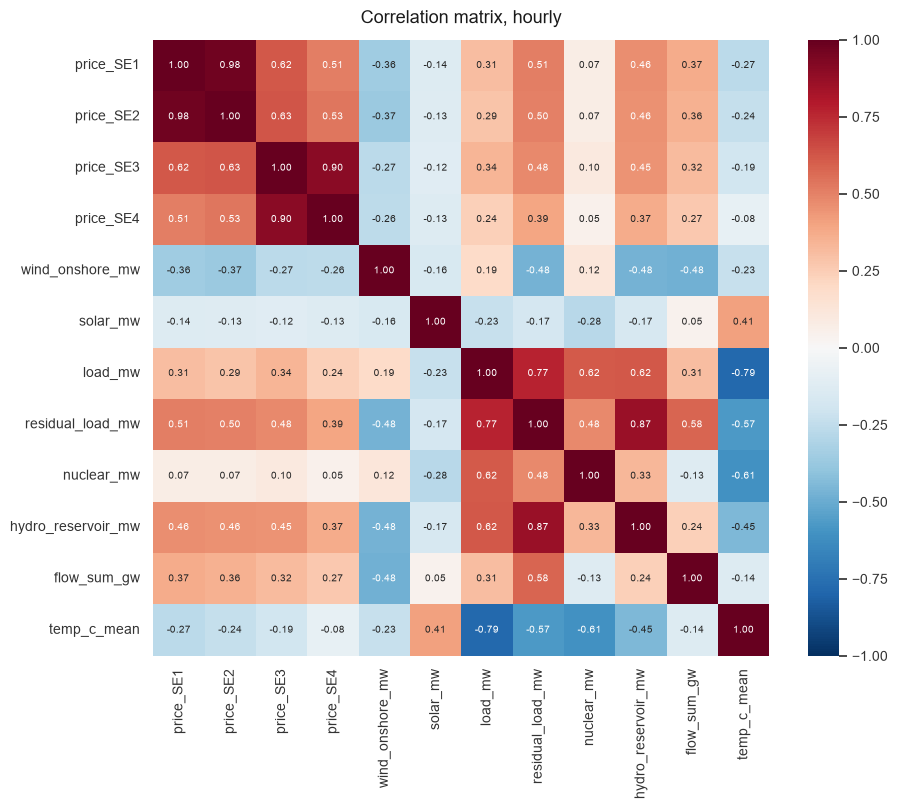

In [21]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix, hourly')
save_fig(fig, '05_correlation_heatmap')
plt.show()

In [22]:
# Anything above 0.8 in absolute value is a multicollinearity warning for the
# modelling stage, not a finding in itself.
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strong = pairs[pairs.abs() > 0.8].sort_values(key=abs, ascending=False)
if len(strong):
    print('pairs with |r| > 0.8:')
    print(strong.round(3).to_string())
else:
    print('no pair exceeds |r| = 0.8')
print()
print('next strongest, for context:')
print(pairs[pairs.abs().between(0.6, 0.8)].sort_values(key=abs, ascending=False).round(3).to_string())

pairs with |r| > 0.8:
price_SE1         price_SE2             0.976
price_SE3         price_SE4             0.904
residual_load_mw  hydro_reservoir_mw    0.866

next strongest, for context:
load_mw     temp_c_mean          -0.788
            residual_load_mw      0.771
price_SE2   price_SE3             0.632
load_mw     hydro_reservoir_mw    0.618
price_SE1   price_SE3             0.618
load_mw     nuclear_mw            0.616
nuclear_mw  temp_c_mean          -0.608


## 6. Time series properties

ADF and KPSS answer opposite questions, so they are run together. ADF has a unit
root as its null, meaning a small p-value is evidence of stationarity. KPSS has
stationarity as its null, so a small p-value is evidence against it. Agreement
between the two is worth more than either alone.

The ADF lag length is chosen by AIC with a ceiling of 24 lags, which is one full
day for hourly data. KPSS p-values are reported by statsmodels only within the
0.01 to 0.10 table range, so a value at either end means beyond the table rather
than an exact figure.

In [23]:
from statsmodels.tsa.stattools import adfuller, kpss


def stationarity_table(series_map, label):
    """Run ADF and KPSS on each series and return one row each."""
    rows = []
    for name, series in series_map.items():
        clean = pd.Series(series).dropna()
        adf_stat, adf_p = adfuller(clean, maxlag=24, autolag='AIC')[:2]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            kpss_stat, kpss_p = kpss(clean, regression='c', nlags='auto')[:2]
        rows.append({
            'series': name,
            'n': len(clean),
            'adf_stat': round(adf_stat, 3),
            'adf_p': round(adf_p, 4),
            'adf_says': 'stationary' if adf_p < 0.05 else 'unit root',
            'kpss_stat': round(kpss_stat, 4),
            'kpss_p': round(kpss_p, 4),
            'kpss_says': 'non-stationary' if kpss_p < 0.05 else 'stationary',
        })
    out = pd.DataFrame(rows)
    out.insert(1, 'transform', label)
    return out

print('running ADF and KPSS, this takes a moment')

running ADF and KPSS, this takes a moment


In [24]:
levels = {f'price_{z}': price_wide[z] for z in ZONES}
levels.update({
    'wind_onshore_mw': national['wind_onshore_mw'],
    'load_mw': national['load_mw'],
    'residual_load_mw': national['residual_load_mw'],
})
diffs = {name: s.diff() for name, s in levels.items()}

tests_levels = stationarity_table(levels, 'levels')
tests_diffs = stationarity_table(diffs, 'first difference')
tests = pd.concat([tests_levels, tests_diffs], ignore_index=True)
tests

,series,transform,n,adf_stat,adf_p,adf_says,kpss_stat,kpss_p,kpss_says
0,price_SE1,levels,42743,-13.131,0.0,stationary,4.0152,0.01,non-stationary
1,price_SE2,levels,42730,-13.641,0.0,stationary,4.3995,0.01,non-stationary
2,price_SE3,levels,42949,-13.564,0.0,stationary,5.3648,0.01,non-stationary
3,price_SE4,levels,43056,-13.087,0.0,stationary,5.1720,0.01,non-stationary
4,wind_onshore_mw,levels,43499,-24.329,0.0,stationary,3.0449,0.01,non-stationary
5,load_mw,levels,43499,-7.401,0.0,stationary,1.1879,0.01,non-stationary
6,residual_load_mw,levels,43499,-23.928,0.0,stationary,4.7837,0.01,non-stationary
7,price_SE1,first difference,42068,-45.981,0.0,stationary,0.0382,0.10,stationary
8,price_SE2,first difference,42087,-46.428,0.0,stationary,0.0268,0.10,stationary
9,price_SE3,first difference,42452,-48.854,0.0,stationary,0.2152,0.10,stationary


In [25]:
# Plain-language reading of the two tests together, series by series.
def verdict(row):
    if row['adf_says'] == 'stationary' and row['kpss_says'] == 'stationary':
        return 'stationary, both tests agree'
    if row['adf_says'] == 'unit root' and row['kpss_says'] == 'non-stationary':
        return 'non-stationary, both tests agree'
    if row['adf_says'] == 'stationary' and row['kpss_says'] == 'non-stationary':
        return 'mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series'
    return 'mixed: neither null is rejected, the series is not clearly either'

tests['reading'] = tests.apply(verdict, axis=1)
for _, row in tests.iterrows():
    print(row['series'].ljust(20), row['transform'].ljust(17), row['reading'])

price_SE1            levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
price_SE2            levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
price_SE3            levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
price_SE4            levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
wind_onshore_mw      levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
load_mw              levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
residual_load_mw     levels            mixed: ADF rejects a unit root but KPSS rejects stationarity, consistent with a persistent series
price_SE1            first difference  st

saved C:\Users\ewuzi\Downloads\Project\figures\06_acf_pacf_se3.png


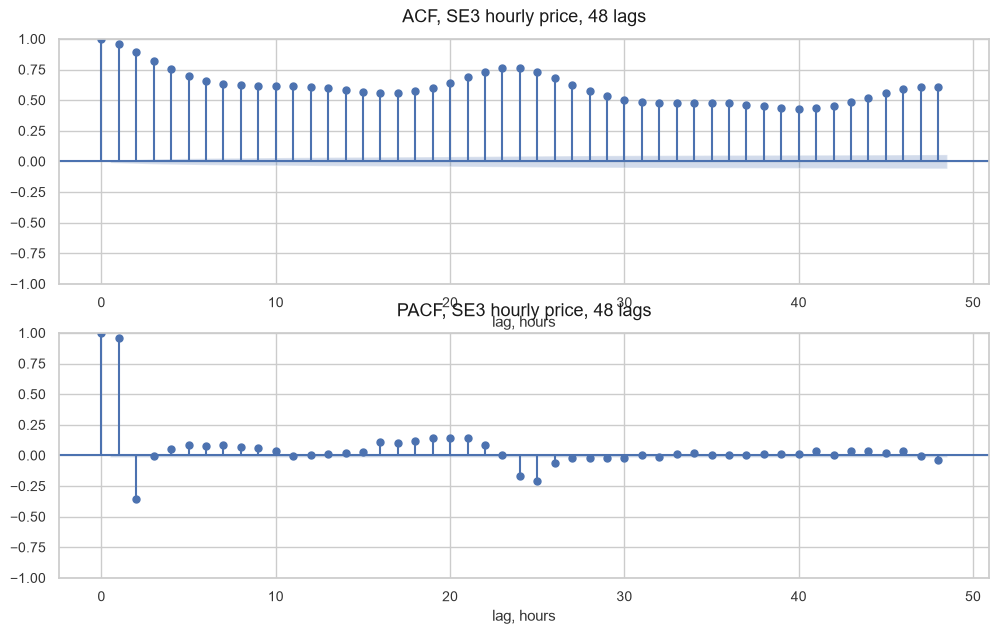

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

se3 = price_wide['SE3'].dropna()
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
plot_acf(se3, lags=48, ax=axes[0])
axes[0].set_title('ACF, SE3 hourly price, 48 lags')
plot_pacf(se3, lags=48, ax=axes[1], method='ywm')
axes[1].set_title('PACF, SE3 hourly price, 48 lags')
for ax in axes:
    ax.set_xlabel('lag, hours')
save_fig(fig, '06_acf_pacf_se3')
plt.show()

## 7. Monthly panel

In [27]:
monthly = monthly.copy()
monthly['date'] = pd.to_datetime(dict(year=monthly['year'], month=monthly['month'], day=1))

PRODUCTION_PARTS = ['hydro_power_including_pump_power_net_gwh',
                    'nuclear_power_condensing_net_gwh',
                    'conventional_thermal_power_net_gwh',
                    'wind_power_gwh',
                    'solar_power_on_grid_gwh']

# Check that the parts really do add up to the reported total before stacking them.
parts_sum = monthly[PRODUCTION_PARTS].sum(axis=1)
gap = (parts_sum - monthly['total_production_gwh'])
print('largest gap between the summed parts and total_production_gwh:',
      round(gap.abs().max(), 2), 'GWh')
print('mean absolute gap:', round(gap.abs().mean(), 3), 'GWh')

largest gap between the summed parts and total_production_gwh: 2.0 GWh
mean absolute gap: 0.146 GWh


saved C:\Users\ewuzi\Downloads\Project\figures\07_production_mix_by_zone.png


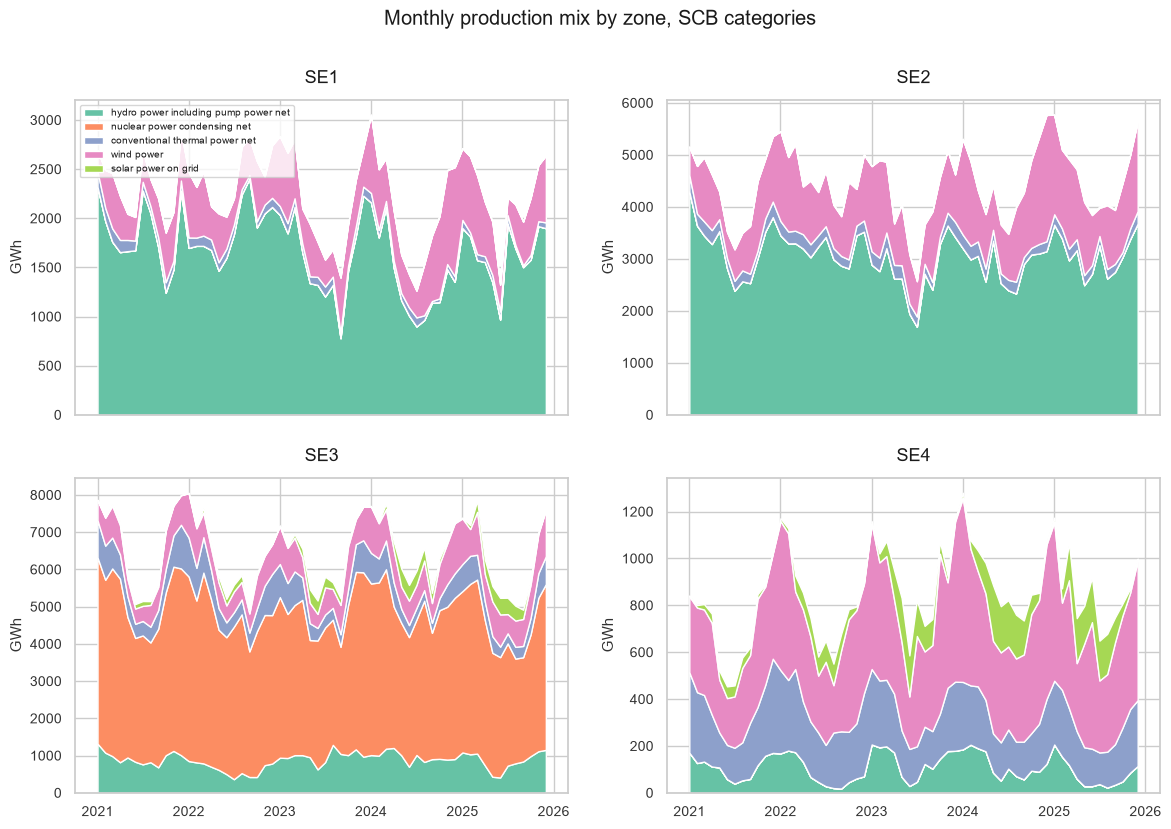

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, zone in zip(axes.flat, ZONES):
    sub = monthly[monthly['zone'] == zone].sort_values('date')
    ax.stackplot(sub['date'], *[sub[c] for c in PRODUCTION_PARTS],
                 labels=[c.replace('_gwh', '').replace('_', ' ') for c in PRODUCTION_PARTS],
                 colors=sns.color_palette('Set2', len(PRODUCTION_PARTS)))
    ax.set_title(zone)
    ax.set_ylabel('GWh')
axes[0, 0].legend(loc='upper left', fontsize=7)
fig.suptitle('Monthly production mix by zone, SCB categories', y=0.98)
save_fig(fig, '07_production_mix_by_zone')
plt.show()

saved C:\Users\ewuzi\Downloads\Project\figures\07_net_position_by_zone.png


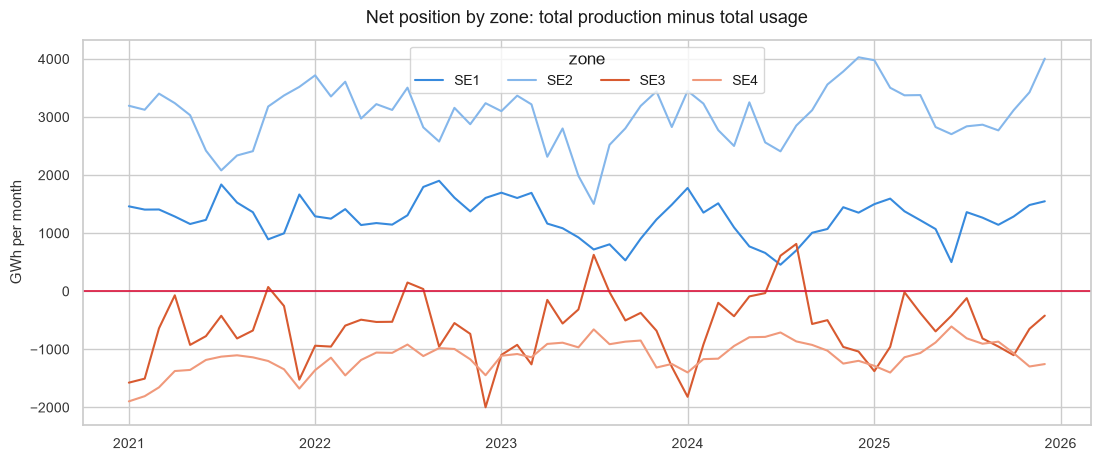

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))
for zone in ZONES:
    sub = monthly[monthly['zone'] == zone].sort_values('date')
    ax.plot(sub['date'], sub['net_position_gwh'], label=zone, color=ZONE_COLOUR[zone])
ax.axhline(0, color='crimson', linewidth=1.2)
ax.set_title('Net position by zone: total production minus total usage')
ax.set_ylabel('GWh per month')
ax.legend(title='zone', ncol=4)
save_fig(fig, '07_net_position_by_zone')
plt.show()

saved C:\Users\ewuzi\Downloads\Project\figures\07_wind_share_vs_price.png


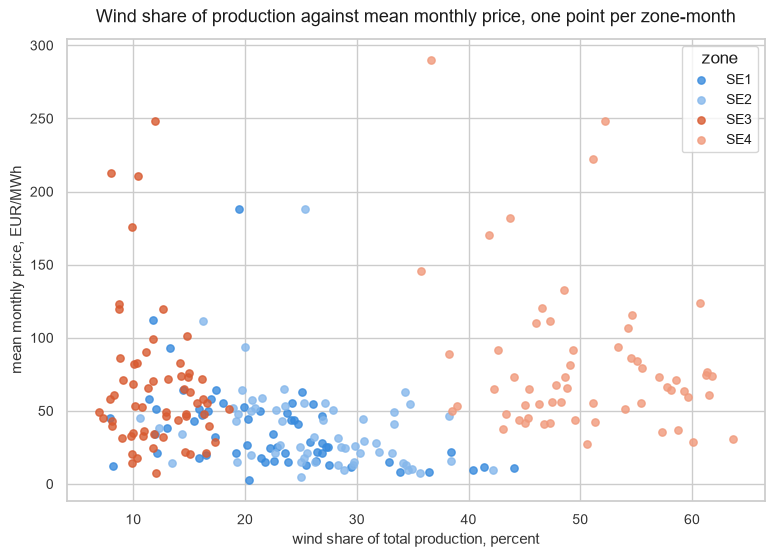

In [30]:
monthly['wind_share'] = 100 * monthly['wind_power_gwh'] / monthly['total_production_gwh']

fig, ax = plt.subplots(figsize=(9, 6))
for zone in ZONES:
    sub = monthly[monthly['zone'] == zone]
    ax.scatter(sub['wind_share'], sub['price_eur_mwh'], label=zone,
               color=ZONE_COLOUR[zone], s=28, alpha=0.8)
ax.set_title('Wind share of production against mean monthly price, one point per zone-month')
ax.set_xlabel('wind share of total production, percent')
ax.set_ylabel('mean monthly price, EUR/MWh')
ax.legend(title='zone')
save_fig(fig, '07_wind_share_vs_price')
plt.show()

In [31]:
print('figures written:')
for name in sorted(os.listdir(FIG_DIR)):
    print(f'  {name:<45} {os.path.getsize(os.path.join(FIG_DIR, name)) / 1024:7.0f} KB')

figures written:
  02_daily_price_by_zone.png                        290 KB
  02_price_boxplot_by_zone.png                       41 KB
  02_spread_se4_se1.png                             142 KB
  03_hexbin_wind_vs_price.png                       495 KB
  03_price_by_wind_decile.png                       129 KB
  03_price_by_wind_decile_by_year.png               198 KB
  04_price_by_hour_and_month.png                    222 KB
  04_wind_and_load_profiles.png                     226 KB
  05_correlation_heatmap.png                        262 KB
  06_acf_pacf_se3.png                               104 KB
  07_net_position_by_zone.png                       216 KB
  07_production_mix_by_zone.png                     445 KB
  07_wind_share_vs_price.png                        151 KB
  08_spread_and_net_position.png                    130 KB
  08_wind_coef_across_specs.png                     129 KB
  08_wind_coef_by_zone.png                           65 KB
  linkedin                             

## 8. What this implies for the modelling

**The level and the spread are two different questions.** SE1 and SE2 are effectively
one market: their hourly prices correlate at 0.98 and the mean SE2 minus SE1 spread
is within 3 EUR/MWh of zero in every year, twice with the sign reversed. SE3 and SE4
correlate at 0.90 with each other but only 0.62 with SE1. A specification that treats
four zones as four independent series is really fitting two pairs.

**2022 is a different regime, not a set of large observations.** SE4 averaged 152
EUR/MWh in 2022 against 50 to 80 in every other year, with a standard deviation of
140 against 50 to 64. The SE4 minus SE1 spread was 93 EUR/MWh against 25 to 43
elsewhere. The wind-decile curve keeps the same downward shape in 2022, just shifted
up, so the mechanism is intact and the level is not. That calls for a 2022 dummy
interacted with the main regressors, or a held-out sub-sample, or a specification in
logs that lets the variance scale. A single additive year dummy will not absorb a
variance change of that size.

**Negative prices are a recent, structural feature.** 6,051 hours, 3.53 percent of
the panel, with a floor at -60.04 EUR/MWh. Fewer than 30 hours per zone in 2021 and
2022, then 350 to 700 per zone per year from 2023 onward. Logs are therefore not
available without an explicit transformation choice, and anything estimated on 2021
to 2022 alone will not see the behaviour that dominates the recent data.

**The merit-order effect is present and monotone.** Mean price falls across all ten
wind deciles in every zone, from 66 to 11 EUR/MWh in SE1 and from 117 to 38 in SE4.
The absolute effect is larger in the south, the proportional effect larger in the
north. Wind belongs in the model in levels, and the interaction with zone is not
optional.

**Stationarity.** Every level series returns the same mixed reading: ADF rejects the
unit root while KPSS rejects stationarity. On 43,000 observations ADF has the power
to reject almost anything, so the KPSS side carries more weight here. Treat the
levels as persistent and close to I(1). Every first difference is stationary on both
tests with no disagreement.

**Cointegration is the next test, not an optional extra.** Four near-I(1) price
series that correlate up to 0.98 are exactly the case where plain differencing throws
away the long-run relationship. Run Johansen on the four prices, or Engle-Granger on
the SE4 minus SE1 pair, before deciding between a VECM with an error-correction term
and a model in differences.

**Autocorrelation.** For SE3 the ACF is 0.96 at lag 1, still 0.82 at lag 3 and 0.61
at lag 12, then rises back to 0.76 at lag 24 and 0.61 at lag 48: slow decay with a
daily cycle on top. The PACF is 0.96 at lag 1, -0.35 at lag 2, near zero after that
except -0.17 at lag 24 and -0.21 at lag 25. Lags 1 and 2 and the lag-24 block are
what matter. Any specification without them will leave serially correlated residuals
and understated standard errors; if the dynamics are left out deliberately, HAC or
cluster-robust errors are the minimum.

**Collinearity.** Three pairs exceed 0.8: price_SE1 with price_SE2 at 0.976,
price_SE3 with price_SE4 at 0.904, and residual load with hydro reservoir output at
0.866. The last is mechanical, since hydro is the balancing resource, so residual
load and hydro output should not enter as separate regressors. Load with mean
temperature at -0.788 and load with residual load at 0.771 are close enough to watch.
Residual load already contains wind by construction, so using both in the same
equation is double counting.

**Two things that were not expected.** SE2 minus SE1 turns slightly negative in 2024
and 2025 after being positive earlier, so the ordering of the two northern zones has
flipped. And 2025 breaks the downward trend in the south: SE3 and SE4 rose to 46 and
60 EUR/MWh while SE1 and SE2 kept falling to 17, widening the SE4 minus SE1 spread
back to 43. Whatever drives that is a southern level shift rather than a national
one, and it is recent enough that a model fitted through 2024 would miss it.

One reassurance: the SCB production categories sum to the reported total to within
2 GWh in the worst month, so the monthly decomposition can be trusted as a share.